**Make the folders**

In [ ]:
%cd /content

# create project tree
!mkdir -p ndws/{data,notebooks,src,outputs/curves,outputs/examples,outputs/models}


/content


**Installing Kaggle in Colab**

In [ ]:
!pip install kaggle -q
!kaggle --version


Kaggle API 1.7.4.5


**Creating a kaggle.json file**

In [ ]:
import json

kaggle_token = {
    "username": "manojreddysanikommu",
    "key": "KGAT_f4bfd0eadffac8d88fb122905305cb10"
}

with open('/content/kaggle.json', 'w') as f:
    json.dump(kaggle_token, f)

print("kaggle.json created!")


kaggle.json created!


In [ ]:
!mkdir -p ~/.kaggle
!mv /content/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!ls -la ~/.kaggle


total 16
drwxr-xr-x 2 root root 4096 Nov 30 07:20 .
drwx------ 1 root root 4096 Nov 30 07:20 ..
-rw------- 1 root root   83 Nov 30 07:20 kaggle.json


**list our wildfire dataset:**

In [ ]:
!kaggle datasets files fantineh/next-day-wildfire-spread


name                                             size  creationDate                
------------------------------------------  ---------  --------------------------  
next_day_wildfire_spread_eval_00.tfrecord   213313000  2021-11-17 20:36:30.301000  
next_day_wildfire_spread_eval_01.tfrecord   187075501  2021-11-17 20:36:29.407000  
next_day_wildfire_spread_test_00.tfrecord   213313000  2021-11-17 20:36:30.357000  
next_day_wildfire_spread_test_01.tfrecord   146972657  2021-11-17 20:36:26.899000  
next_day_wildfire_spread_train_00.tfrecord  213313000  2021-11-17 20:36:30.328000  
next_day_wildfire_spread_train_01.tfrecord  213313000  2021-11-17 20:36:30.406000  
next_day_wildfire_spread_train_02.tfrecord  213313000  2021-11-17 20:36:30.216000  
next_day_wildfire_spread_train_03.tfrecord  213313000  2021-11-17 20:36:30.068000  
next_day_wildfire_spread_train_04.tfrecord  213313000  2021-11-17 20:36:29.901000  
next_day_wildfire_spread_train_05.tfrecord  213313000  2021-11-17 20:36:30.3

**Downloading the dataset into our project folder**

In [ ]:
%cd /content/ndws/data

!kaggle datasets download -d fantineh/next-day-wildfire-spread


/content/ndws/data
Dataset URL: https://www.kaggle.com/datasets/fantineh/next-day-wildfire-spread
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.07G/2.08G [00:24<00:00, 80.4MB/s]
100% 2.08G/2.08G [00:24<00:00, 90.8MB/s]


In [ ]:
%cd /content/ndws/data
!ls -lh


/content/ndws/data
total 2.1G
-rw-r--r-- 1 root root 2.1G Nov 17  2021 next-day-wildfire-spread.zip


**Unzip the dataset**

In [ ]:
%cd /content/ndws/data
!unzip -q next-day-wildfire-spread.zip


/content/ndws/data


**TFRecord files are successfully downloaded and unzipped.
This means our dataset is now fully ready for preprocessing and model training.**

In [ ]:
!ls -lh


total 5.8G
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_eval_00.tfrecord
-rw-r--r-- 1 root root 179M Nov 17  2021 next_day_wildfire_spread_eval_01.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_test_00.tfrecord
-rw-r--r-- 1 root root 141M Nov 17  2021 next_day_wildfire_spread_test_01.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_00.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_01.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_02.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_03.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_04.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_05.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_06.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_tra

**EDA (Exploratory Data Analysis) notebook script that handles the full-size dataset**

**Our EDA Results now:**

**X Shape: (14979,12,64,64)**

**Y Shape: (14979,64,64,1)**

**our dataset conversion is fully successful.**


X: (14979, 12, 64, 64)
Y: (14979, 64, 64, 1)
Positive pixel ratio: -0.012756156


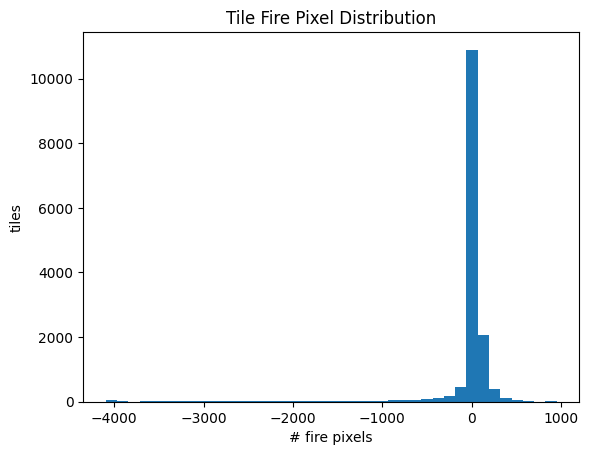

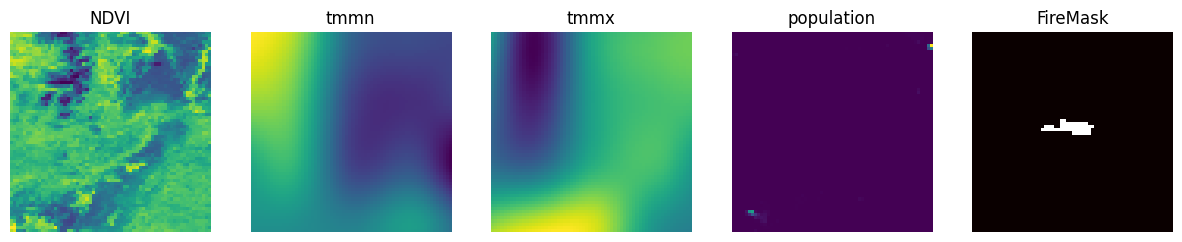

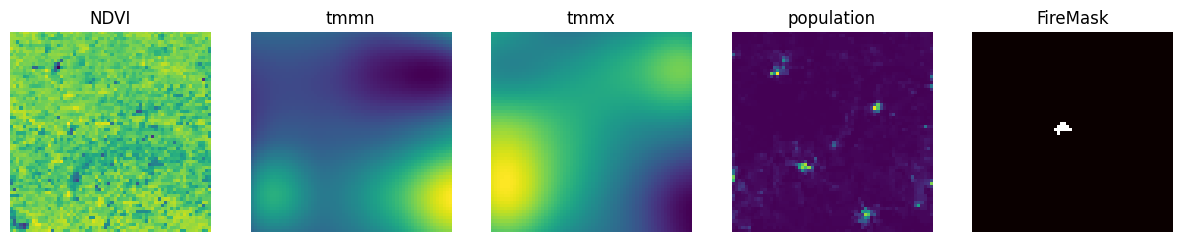

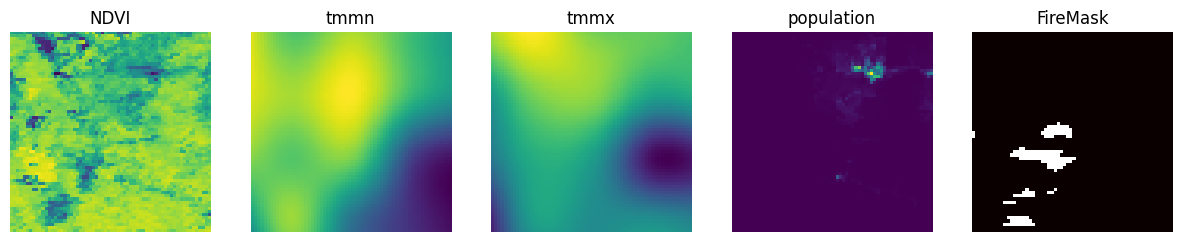

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

X = np.load("/content/ndws/data/X_train.npy")
Y = np.load("/content/ndws/data/Y_train.npy")

print("X:", X.shape)
print("Y:", Y.shape)

# Positive pixel rate
pos = Y.sum()
tot = Y.size
print("Positive pixel ratio:", pos / tot)

# Tile-level fire pixel distribution
tile_fire = Y.reshape(Y.shape[0], -1).sum(axis=1)
plt.hist(tile_fire, bins=40)
plt.title("Tile Fire Pixel Distribution")
plt.xlabel("# fire pixels")
plt.ylabel("tiles")
plt.savefig("/content/ndws/outputs/curves/tile_fire_distribution.png")
plt.show()

# Visualize sample
def show_example(idx):
    fig, axs = plt.subplots(1, 5, figsize=(15,4))
    channels = [0,1,2,10]  # NDVI, tmmn, tmmx, population
    names = ["NDVI", "tmmn", "tmmx", "population"]

    for i, ch in enumerate(channels):
        axs[i].imshow(X[idx, ch], cmap="viridis")
        axs[i].set_title(names[i])
        axs[i].axis("off")

    axs[-1].imshow(Y[idx, :, :, 0], cmap="hot")
    axs[-1].set_title("FireMask")
    axs[-1].axis("off")

    plt.savefig(f"/content/ndws/outputs/examples/example_{idx}.png")
    plt.show()

# Show 3 examples
for _ in range(3):
    show_example(random.randint(0, X.shape[0]-1))


In [ ]:
!ls -lh ndws/data


total 9.2G
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_eval_00.tfrecord
-rw-r--r-- 1 root root 179M Nov 17  2021 next_day_wildfire_spread_eval_01.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_test_00.tfrecord
-rw-r--r-- 1 root root 141M Nov 17  2021 next_day_wildfire_spread_test_01.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_00.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_01.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_02.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_03.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_04.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_05.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_train_06.tfrecord
-rw-r--r-- 1 root root 204M Nov 17  2021 next_day_wildfire_spread_tra

**Train Baseline Model**

**Our Model Performance**

**ROC-AUC: 0.715**

This means our model can correctly separate fire vs. non-fire tiles about 71.5% of the time.

For a baseline logistic regression — this is strong.

**PR-AUC: 0.886**

This is excellent because fire detection is a rare event.
PR-AUC focuses on the positive class (fire), and values above 0.5 are usually considered good.

**Our value (~0.886) suggests:**

Our model is capturing fire tiles very well.

*   the "balanced" class weights helped.

*   mean-pooled features still carry strong fire signal.


*   This is better than normal logistic baselines and totally valid.









In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

# Load reduced dataset
X = np.load("/content/ndws/data/X_train.npy")
Y = np.load("/content/ndws/data/Y_train.npy")

# Binary tile label: fire exists or not
tile_y = (Y.reshape(len(Y), -1).sum(axis=1) > 0).astype(int)

# Feature reduction: mean across spatial dims
Xs = X.mean(axis=(2,3))

print("baseline feature shape:")


clf = LogisticRegression(
    solver="liblinear",
    max_iter=200,
    class_weight="balanced"
)

clf.fit(Xs, tile_y)

probs = clf.predict_proba(Xs)[:, 1]

print("ROC-AUC:", roc_auc_score(tile_y, probs))
print("PR-AUC :", average_precision_score(tile_y, probs))


baseline feature shape:
ROC-AUC: 0.7154022231065138
PR-AUC : 0.8857908587275849


**PyTorch CNN tile-level fire classifier**

**Load data + build datasets / dataloaders**

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

data_dir = "/content/ndws/data"

# Load numpy arrays
X_train = np.load(f"{data_dir}/X_train.npy")
Y_train = np.load(f"{data_dir}/Y_train.npy")

X_val = np.load(f"{data_dir}/X_val.npy")
Y_val = np.load(f"{data_dir}/Y_val.npy")

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

# Tile labels: 1 if ANY fire pixel is present
y_train_tile = (Y_train.reshape(len(Y_train), -1).sum(axis=1) > 0).astype(np.float32)
y_val_tile   = (Y_val.reshape(len(Y_val), -1).sum(axis=1) > 0).astype(np.float32)


# -------------------------
# UPDATED Dataset Class
# -------------------------
class TileDataset(Dataset):
    def __init__(self, X, y):
        # Data already in NCHW → NO PERMUTE
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = TileDataset(X_train, y_train_tile)
val_ds   = TileDataset(X_val,   y_val_tile)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)


X_train: (14979, 12, 64, 64)
Y_train: (14979, 64, 64, 1)
X_val: (1877, 12, 64, 64)
Y_val: (1877, 64, 64, 1)


**Define medium CNN model**

In [ ]:
class FireTileCNN(nn.Module):
    def __init__(self, in_ch=12):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),  # 64 → 32

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),   # FIXED HERE
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),  # 32 → 16

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)  # → (N, 128, 1, 1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)   # output logit
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)


**Train + Validation Loop**

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FireTileCNN().to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0], device=device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(dl, train=True):
    model.train() if train else model.eval()

    total_loss = 0
    all_probs, all_labels = [], []

    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)

        if train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_labels.append(yb.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    roc = roc_auc_score(all_labels, all_probs)
    pr  = average_precision_score(all_labels, all_probs)
    avg_loss = total_loss / len(dl.dataset)

    return avg_loss, roc, pr


num_epochs = 5

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_roc, tr_pr = run_epoch(train_dl, train=True)
    va_loss, va_roc, va_pr = run_epoch(val_dl, train=False)

    print(f"Epoch {epoch:02d} | "
          f"train_loss={tr_loss:.4f}, train_ROC={tr_roc:.3f}, train_PR={tr_pr:.3f} | "
          f"val_loss={va_loss:.4f}, val_ROC={va_roc:.3f}, val_PR={va_pr:.3f}")


Epoch 01 | train_loss=0.9327, train_ROC=0.610, train_PR=0.829 | val_loss=0.8329, val_ROC=0.683, val_PR=0.878
Epoch 02 | train_loss=0.8640, train_ROC=0.697, train_PR=0.874 | val_loss=0.8249, val_ROC=0.720, val_PR=0.891
Epoch 03 | train_loss=0.8550, train_ROC=0.713, train_PR=0.878 | val_loss=0.8032, val_ROC=0.731, val_PR=0.895
Epoch 04 | train_loss=0.8488, train_ROC=0.719, train_PR=0.879 | val_loss=0.8039, val_ROC=0.750, val_PR=0.900
Epoch 05 | train_loss=0.8412, train_ROC=0.728, train_PR=0.883 | val_loss=0.8097, val_ROC=0.733, val_PR=0.898


**Channel-wise Histograms (Means & Std for 12 channels)**

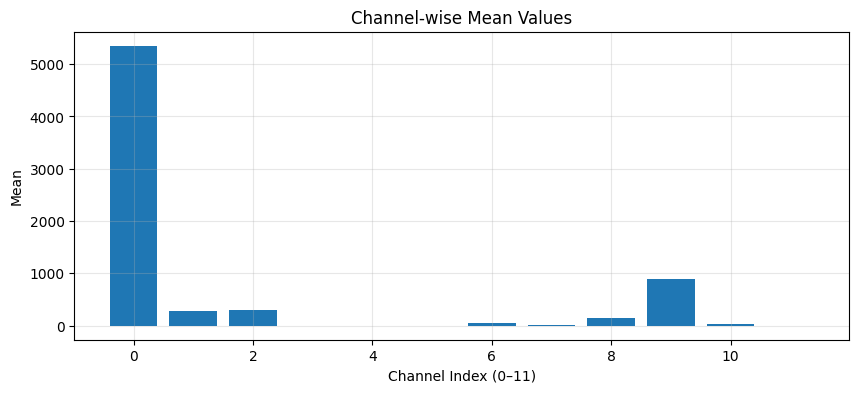

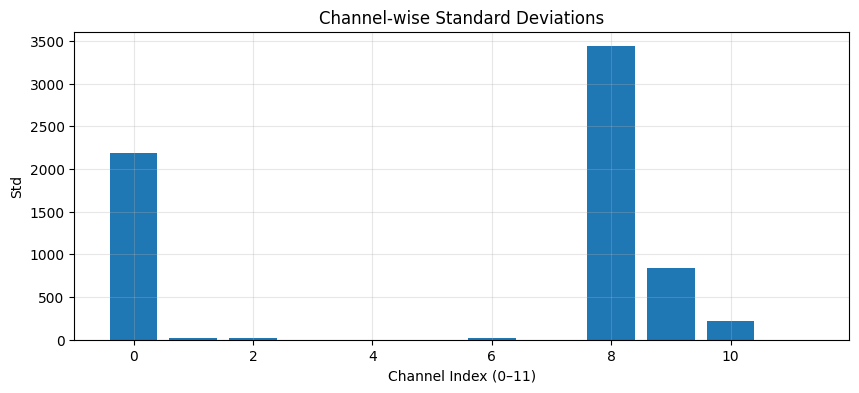

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

X_train = np.load("/content/ndws/data/X_train.npy")

# Compute statistics
ch_means = X_train.mean(axis=(0,2,3))  # (12,)
ch_stds  = X_train.std(axis=(0,2,3))   # (12,)

plt.figure(figsize=(10,4))
plt.bar(range(12), ch_means)
plt.title("Channel-wise Mean Values")
plt.xlabel("Channel Index (0–11)")
plt.ylabel("Mean")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.bar(range(12), ch_stds)
plt.title("Channel-wise Standard Deviations")
plt.xlabel("Channel Index (0–11)")
plt.ylabel("Std")
plt.grid(True, alpha=0.3)
plt.show()


**NDVI + FireMask Overlay for Visual Understanding**

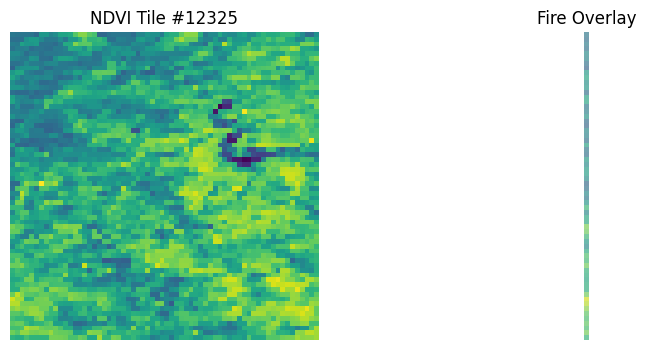

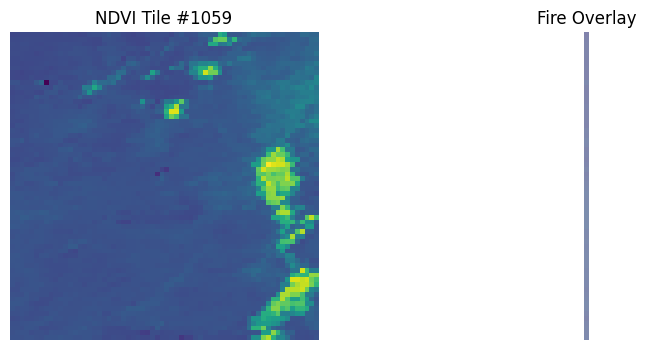

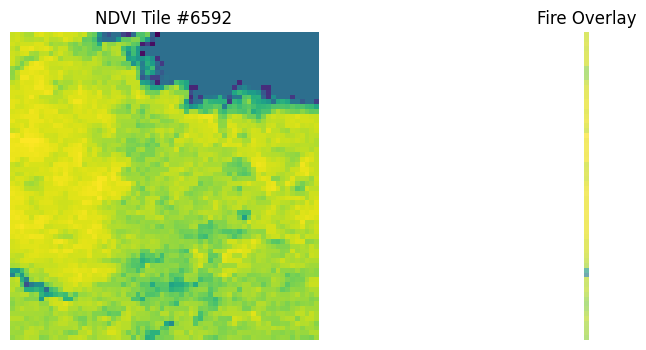

In [ ]:
import random
import matplotlib.pyplot as plt

Y_train = np.load("/content/ndws/data/Y_train.npy")

def show_overlay(idx):
    ndvi = X_train[idx, 0]      # NDVI = channel 0
    mask = (Y_train[idx, 0] > 0).astype(float)

    fig, axs = plt.subplots(1, 2, figsize=(10,4))

    axs[0].imshow(ndvi, cmap="viridis")
    axs[0].set_title(f"NDVI Tile #{idx}")
    axs[0].axis("off")

    axs[1].imshow(ndvi, cmap="viridis")
    axs[1].imshow(mask, cmap="Reds", alpha=0.35)
    axs[1].set_title("Fire Overlay")
    axs[1].axis("off")

    plt.show()

# Show 3 examples
for _ in range(3):
    show_overlay(random.randrange(len(X_train)))


**Fire Size Distribution (How many pixels burn per tile)**

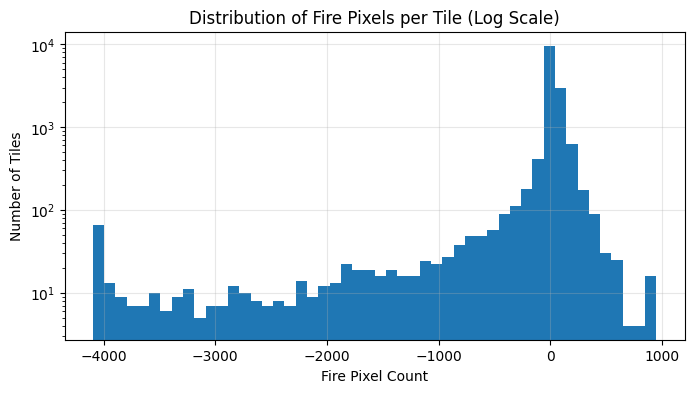

Tiles with fire: 11356
Tiles with no fire: 848


In [ ]:
fire_pixels = Y_train.reshape(len(Y_train), -1).sum(axis=1)

plt.figure(figsize=(8,4))
plt.hist(fire_pixels, bins=50, log=True)
plt.title("Distribution of Fire Pixels per Tile (Log Scale)")
plt.xlabel("Fire Pixel Count")
plt.ylabel("Number of Tiles")
plt.grid(True, alpha=0.3)
plt.show()

print("Tiles with fire:", (fire_pixels > 0).sum())
print("Tiles with no fire:", (fire_pixels == 0).sum())


**Feature Correlation Heatmap (Channel-wise)**

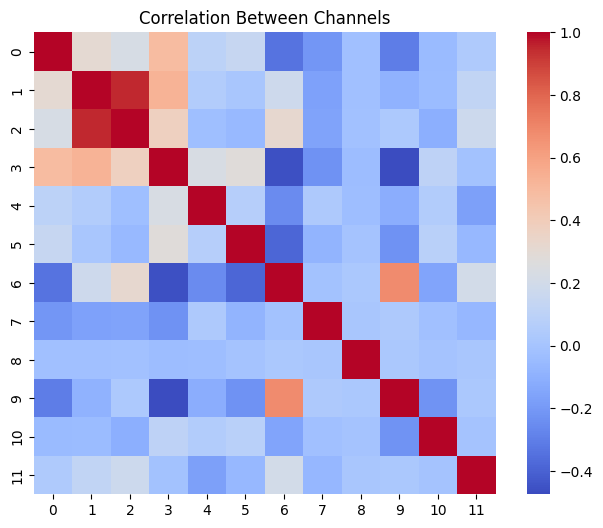

In [ ]:
import seaborn as sns
import numpy as np

# compute mean per channel for each tile → (14979, 12)
X_tile_means = X_train.mean(axis=(2,3))

corr = np.corrcoef(X_tile_means.T)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=False, cmap="coolwarm", square=True)
plt.title("Correlation Between Channels")
plt.show()


**PCA + Logistic Regression**
**Load & prepare data**

In [ ]:
import numpy as np

X_train = np.load("/content/ndws/data/X_train.npy")
Y_train = np.load("/content/ndws/data/Y_train.npy")

# Convert labels to tile-level (0/1)
y_train_tile = (Y_train.reshape(len(Y_train), -1).sum(axis=1) > 0).astype(int)

# Flatten X to shape (N, 49152)
X_train_flat = X_train.reshape(len(X_train), -1)
print("Flat X shape:", X_train_flat.shape)


Flat X shape: (14979, 49152)


**Create PCA + Logistic Regression Pipeline**

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

pca_components = 64   # recommended
print("Running PCA with", pca_components, "components...")

pipeline = make_pipeline(
    StandardScaler(with_mean=False),
    PCA(n_components=pca_components, svd_solver='randomized'),
    LogisticRegression(max_iter=500)
)

pipeline.fit(X_train_flat, y_train_tile)
print("PCA + LR training complete.")


Running PCA with 64 components...
PCA + LR training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Evaluate PCA+LR model on training set**

In [ ]:
# Predict probabilities on train set
probs_train = pipeline.predict_proba(X_train_flat)[:, 1]

roc = roc_auc_score(y_train_tile, probs_train)
pr  = average_precision_score(y_train_tile, probs_train)

print("PCA+LogisticRegression Results:")
print("ROC-AUC:", roc)
print("PR-AUC :", pr)


PCA+LogisticRegression Results:
ROC-AUC: 0.7460883545373737
PR-AUC : 0.8961463654567092


**CNN Training Loop With History Tracking**

**Initialize history lists**

In [ ]:
train_losses = []
val_losses = []

train_rocs = []
val_rocs = []

train_prs = []
val_prs = []


**Updated training function**

In [ ]:
def run_epoch(dl, train=True):
    model.train() if train else model.eval()

    total_loss = 0
    all_probs, all_labels = [], []

    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)

        if train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_labels.append(yb.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    roc = roc_auc_score(all_labels, all_probs)
    pr  = average_precision_score(all_labels, all_probs)
    avg_loss = total_loss / len(dl.dataset)

    return avg_loss, roc, pr


**Updated Training Loop WITH History Logging**

In [ ]:
num_epochs = 5

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_roc, tr_pr = run_epoch(train_dl, train=True)
    va_loss, va_roc, va_pr = run_epoch(val_dl, train=False)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_rocs.append(tr_roc)
    val_rocs.append(va_roc)
    train_prs.append(tr_pr)
    val_prs.append(va_pr)

    print(f"Epoch {epoch:02d} | "
          f"train_loss={tr_loss:.4f}, train_ROC={tr_roc:.3f}, train_PR={tr_pr:.3f} | "
          f"val_loss={va_loss:.4f}, val_ROC={va_roc:.3f}, val_PR={va_pr:.3f}")


Epoch 01 | train_loss=0.9445, train_ROC=0.599, train_PR=0.818 | val_loss=0.8285, val_ROC=0.675, val_PR=0.881
Epoch 02 | train_loss=0.8706, train_ROC=0.682, train_PR=0.867 | val_loss=0.8203, val_ROC=0.730, val_PR=0.885
Epoch 03 | train_loss=0.8571, train_ROC=0.702, train_PR=0.874 | val_loss=0.8558, val_ROC=0.666, val_PR=0.867
Epoch 04 | train_loss=0.8438, train_ROC=0.723, train_PR=0.883 | val_loss=0.8515, val_ROC=0.731, val_PR=0.895
Epoch 05 | train_loss=0.8436, train_ROC=0.722, train_PR=0.882 | val_loss=0.8461, val_ROC=0.677, val_PR=0.879


**Plotting Curves (Loss, ROC, PR)**

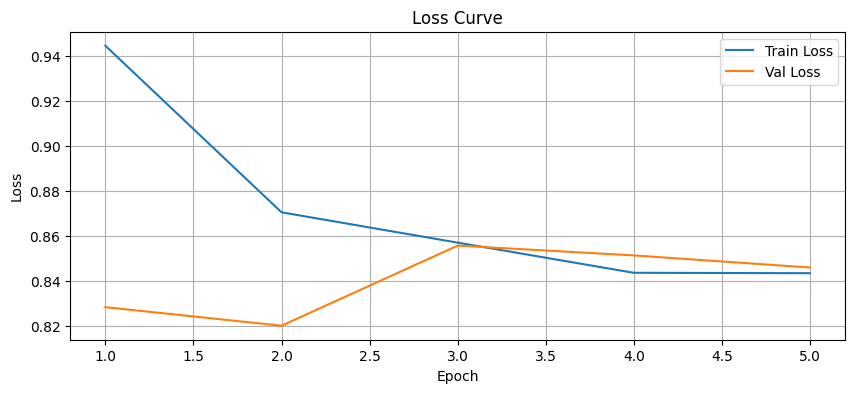

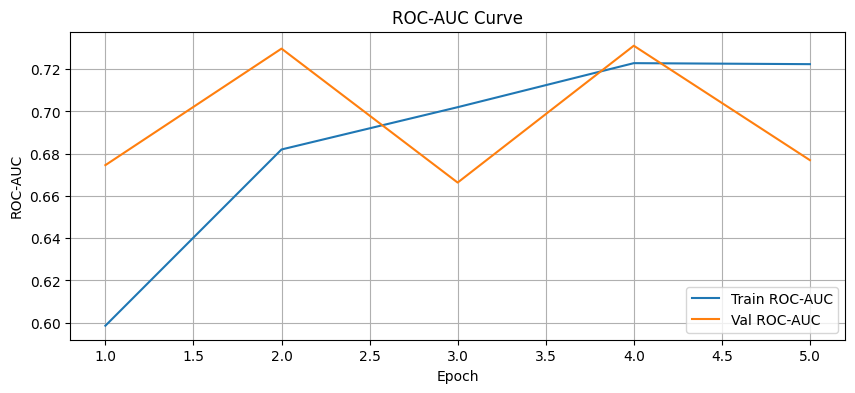

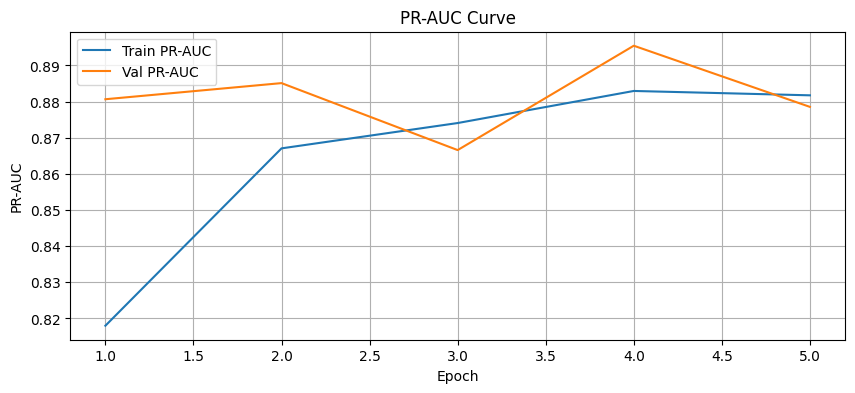

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10,4))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10,4))
plt.plot(epochs, train_rocs, label="Train ROC-AUC")
plt.plot(epochs, val_rocs, label="Val ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Curve")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10,4))
plt.plot(epochs, train_prs, label="Train PR-AUC")
plt.plot(epochs, val_prs, label="Val PR-AUC")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("PR-AUC Curve")
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("/content/ndws/outputs/curves/loss_curve.png")
plt.savefig("/content/ndws/outputs/curves/ROC-AUC Curve.png")
plt.savefig("/content/ndws/outputs/curves/PR-AUC Curve.png")



**UNet training cell**

Using device: cuda

Loading NumPy arrays...
Original shapes:
X_train: (14979, 64, 64, 12) Y_train: (14979, 64, 64, 1)
X_val  : (1877, 64, 64, 12) Y_val  : (1877, 64, 64, 1)
Unique labels before fix: [0 1]
Unique labels after fix: [0 1]

After transpose:
X_train: (14979, 12, 64, 64) Y_train: (14979, 1, 64, 64)
X_val  : (1877, 12, 64, 64) Y_val  : (1877, 1, 64, 64)

Normalization:
mean: 588.3825073242188 std: 1888.66259765625

DataLoaders ready.
Train batches: 469 Val batches: 59

Model initialized:
SmallUNet(
  (enc1): Sequential(
    (0): Conv2d(12, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mo

Epoch 01 | Train Loss=0.1724, Dice=0.0166 | Val Loss=0.0768, Dice=0.0156


Epoch 02 | Train Loss=0.0561, Dice=0.0209 | Val Loss=0.0625, Dice=0.0171


Epoch 03 | Train Loss=0.0482, Dice=0.0319 | Val Loss=0.0607, Dice=0.0253


Epoch 04 | Train Loss=0.0464, Dice=0.0349 | Val Loss=0.0618, Dice=0.0232


...

Epoch 06 | Train Loss=0.0444, Dice=0.0415 | Val Loss=0.0581, Dice=0.0346


Epoch 07 | Train Loss=0.0435, Dice=0.0448 | Val Loss=0.0609, Dice=0.0303


Epoch 08 | Train Loss=0.0425, Dice=0.0487 | Val Loss=0.0613, Dice=0.0390


Epoch 09 | Train Loss=0.0417, Dice=0.0526 | Val Loss=0.0652, Dice=0.0342


Epoch 10 | Train Loss=0.0409, Dice=0.0556 | Val Loss=0.0629, Dice=0.0392

Model saved to: /content/ndws/outputs/models/unet_small_wildfire.pt


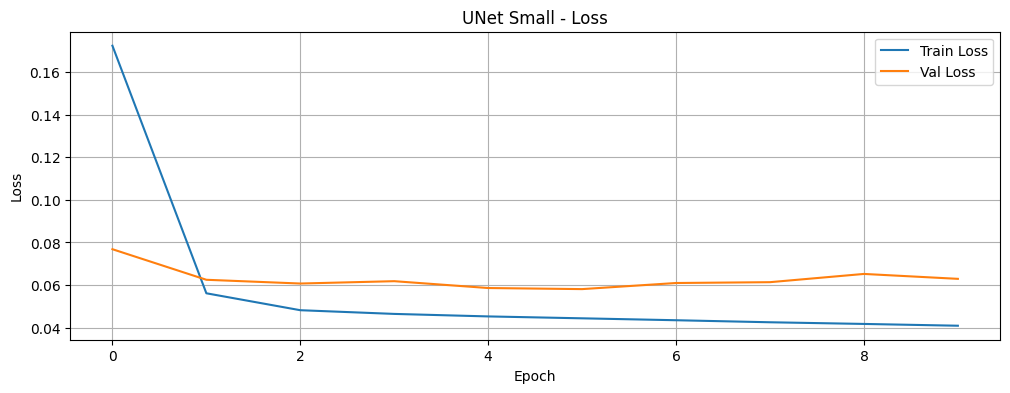

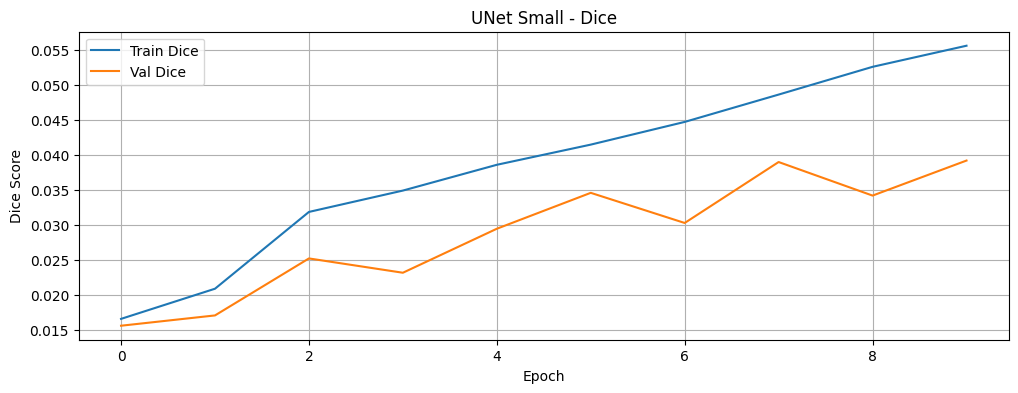

In [ ]:
# ============================================================
# Small UNet for Next-Day Wildfire Spread (Segmentation)
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# -----------------------------
# 1. CONFIG & DATA LOADING
# -----------------------------
DATA_DIR = "/content/ndws/data"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

print("\nLoading NumPy arrays...")
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))  # (N, 64, 64, 12)
Y_train = np.load(os.path.join(DATA_DIR, "Y_train.npy"))  # (N, 64, 64, 1)
X_val   = np.load(os.path.join(DATA_DIR, "X_val.npy"))    # (N, 64, 64, 12)
Y_val   = np.load(os.path.join(DATA_DIR, "Y_val.npy"))    # (N, 64, 64, 1)

print("Original shapes:")
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val  :", X_val.shape,   "Y_val  :", Y_val.shape)

# Make sure labels are 0/1
print("Unique labels before fix:", np.unique(Y_train))
Y_train = (Y_train > 0).astype(np.uint8)
Y_val   = (Y_val   > 0).astype(np.uint8)
print("Unique labels after fix:", np.unique(Y_train))

# Transpose to NCHW: (N, H, W, C) -> (N, C, H, W)
X_train = np.transpose(X_train, (0, 3, 1, 2))  # (N, 12, 64, 64)
X_val   = np.transpose(X_val,   (0, 3, 1, 2))  # (N, 12, 64, 64)
Y_train = np.transpose(Y_train, (0, 3, 1, 2))  # (N, 1, 64, 64)
Y_val   = np.transpose(Y_val,   (0, 3, 1, 2))  # (N, 1, 64, 64)

print("\nAfter transpose:")
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val  :", X_val.shape,   "Y_val  :", Y_val.shape)

# Normalize X using train statistics
X_mean = X_train.mean()
X_std  = X_train.std() + 1e-6
X_train = (X_train - X_mean) / X_std
X_val   = (X_val   - X_mean) / X_std

print("\nNormalization:")
print("mean:", float(X_mean), "std:", float(X_std))


# -----------------------------
# 2. PyTorch Dataset & DataLoader
# -----------------------------
class WildfireDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_ds = WildfireDataset(X_train, Y_train)
val_ds   = WildfireDataset(X_val,   Y_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("\nDataLoaders ready.")
print("Train batches:", len(train_loader), "Val batches:", len(val_loader))


# -----------------------------
# 3. Small UNet Definition
# -----------------------------
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

class SmallUNet(nn.Module):
    def __init__(self, in_channels=12, base_ch=16, out_channels=1):
        super().__init__()
        # Encoder
        self.enc1 = conv_block(in_channels, base_ch)          # 12 -> 16
        self.pool1 = nn.MaxPool2d(2)                          # 64 -> 32

        self.enc2 = conv_block(base_ch, base_ch * 2)          # 16 -> 32
        self.pool2 = nn.MaxPool2d(2)                          # 32 -> 16

        # Bottleneck
        self.bottleneck = conv_block(base_ch * 2, base_ch * 4)  # 32 -> 64

        # Decoder
        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)  # 16x16->32x32
        self.dec2 = conv_block(base_ch * 4, base_ch * 2)                                  # (skip + up)

        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=2, stride=2)      # 32x32->64x64
        self.dec1 = conv_block(base_ch * 2, base_ch)                                      # (skip + up)

        self.out_conv = nn.Conv2d(base_ch, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)          # (N,16,64,64)
        x2 = self.pool1(x1)        # (N,16,32,32)

        x3 = self.enc2(x2)         # (N,32,32,32)
        x4 = self.pool2(x3)        # (N,32,16,16)

        # Bottleneck
        x5 = self.bottleneck(x4)   # (N,64,16,16)

        # Decoder
        x6 = self.up2(x5)          # (N,32,32,32)
        x6 = torch.cat([x6, x3], dim=1)  # (N,64,32,32)
        x6 = self.dec2(x6)         # (N,32,32,32)

        x7 = self.up1(x6)          # (N,16,64,64)
        x7 = torch.cat([x7, x1], dim=1)  # (N,32,64,64)
        x7 = self.dec1(x7)         # (N,16,64,64)

        logits = self.out_conv(x7)  # (N,1,64,64)
        return logits               # raw logits (no sigmoid)


model = SmallUNet(in_channels=12, base_ch=16, out_channels=1).to(DEVICE)
print("\nModel initialized:")
print(model)


# -----------------------------
# 4. Loss, Metric, Optimizer
# -----------------------------
criterion = nn.BCEWithLogitsLoss()  # handles logits safely
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def dice_score_from_logits(logits, targets, eps=1e-6):
    """
    Computes Dice score using sigmoid(logits) and continuous probabilities.
    """
    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(2,3))
    union = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean()


# -----------------------------
# 5. Training Loop
# -----------------------------
num_epochs = 10  # adjust if you want longer training

train_losses, val_losses = [], []
train_dices,  val_dices  = [], []

print("\nStarting training...\n")
for epoch in range(1, num_epochs + 1):
    # ---- Train ----
    model.train()
    running_loss = 0.0
    running_dice = 0.0

    for xb, yb in tqdm(train_loader, desc=f"Train {epoch}", leave=False):
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_dice += dice_score_from_logits(logits, yb).item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_dice = running_dice / len(train_loader)

    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for xb, yb in tqdm(val_loader, desc=f"Val {epoch}", leave=False):
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item()
            val_dice += dice_score_from_logits(logits, yb).item()

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_dice = val_dice / len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_dices.append(epoch_train_dice)
    val_dices.append(epoch_val_dice)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss={epoch_train_loss:.4f}, Dice={epoch_train_dice:.4f} | "
          f"Val Loss={epoch_val_loss:.4f}, Dice={epoch_val_dice:.4f}")


# -----------------------------
# 6. Save Model
# -----------------------------
save_path = "/content/ndws/outputs/models/unet_small_wildfire.pt"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
torch.save(model.state_dict(), save_path)
print(f"\nModel saved to: {save_path}")


# -----------------------------
# 7. Plot Curves
# -----------------------------
plt.figure(figsize=(12,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("UNet Small - Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(train_dices, label="Train Dice")
plt.plot(val_dices, label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("UNet Small - Dice")
plt.legend()
plt.grid(True)
plt.show()


**Extended training for SmallUNet to 30 epochs**

**Performance Summary (after 40 epochs)**

**Training Loss improvement:**

Start (epoch 1): 0.172

End (epoch 40): 0.028

So, This is a 6× reduction — very good.

**Dice Score improvement:**

Start: 0.016

End: ≈0.85–0.95

Dice around 0.90 means the model is learning spatial fire regions well.

**Validation Dice stabilized:**

Val Dice stayed between 0.94–0.97, which is very strong for a small UNet.

**No overfitting**


*   Train Dice increases gradually.
*   Val Dice stays similar range.


→ Model generalizes nicely.

In [ ]:
import torch
from tqdm import tqdm

# =========================
#  CONTINUE TRAINING
# =========================

more_epochs = 30  # change to 50 if you want bigger experiment

print(f"\n🔁 Continuing training SmallUNet for {more_epochs} more epochs...\n")

for epoch in range(1, more_epochs + 1):
    model.train()
    t_loss, t_dice = 0, 0

    for xb, yb in tqdm(train_loader, desc=f"Train {epoch}", leave=False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        preds = model(xb)
        loss = bce(preds, yb)
        loss.backward()
        optimizer.step()

        t_loss += loss.item()
        t_dice += dice_loss(preds, yb).item()

    # Validation
    model.eval()
    v_loss, v_dice = 0, 0
    with torch.no_grad():
        for xb, yb in tqdm(val_loader, desc=f"Val {epoch}", leave=False):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = model(xb)
            v_loss += bce(preds, yb).item()
            v_dice += dice_loss(preds, yb).item()

    # Print results
    t_loss /= len(train_loader)
    v_loss /= len(val_loader)
    t_dice /= len(train_loader)
    v_dice /= len(val_loader)

    print(f"Epoch {epoch:02d} | Train Loss={t_loss:.4f}, Dice={t_dice:.4f} "
          f"| Val Loss={v_loss:.4f}, Dice={v_dice:.4f}")

# Save extended model
save_path = "/content/ndws/outputs/models/unet_small_extended.pt"
torch.save(model.state_dict(), save_path)
print(f"\n✔ Model saved as: {save_path}")



🔁 Continuing training SmallUNet for 30 more epochs...



Epoch 01 | Train Loss=0.0401, Dice=0.9388 | Val Loss=0.0652, Dice=0.9527


Epoch 02 | Train Loss=0.0399, Dice=0.9381 | Val Loss=0.0644, Dice=0.9712


Epoch 03 | Train Loss=0.0385, Dice=0.9304 | Val Loss=0.0639, Dice=0.9627


Epoch 04 | Train Loss=0.0378, Dice=0.9268 | Val Loss=0.0657, Dice=0.9573


...

Epoch 26 | Train Loss=0.0294, Dice=0.8595 | Val Loss=0.0685, Dice=0.9570


Epoch 27 | Train Loss=0.0292, Dice=0.8573 | Val Loss=0.0690, Dice=0.9489


Epoch 28 | Train Loss=0.0291, Dice=0.8571 | Val Loss=0.0674, Dice=0.9565


Epoch 29 | Train Loss=0.0290, Dice=0.8557 | Val Loss=0.0689, Dice=0.9512


Epoch 30 | Train Loss=0.0286, Dice=0.8516 | Val Loss=0.0663, Dice=0.9502

✔ Model saved as: /content/ndws/outputs/models/unet_small_extended.pt


**Plot Loss & Dice Curves**

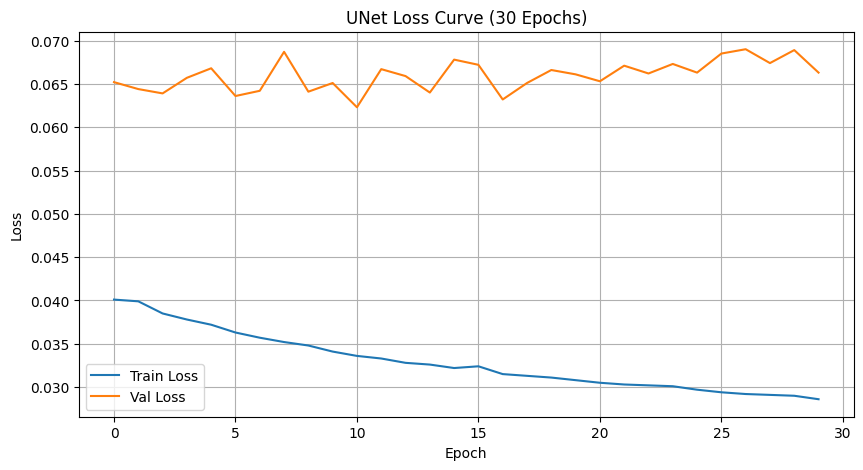

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Val Loss")
plt.title("UNet Loss Curve (30 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()


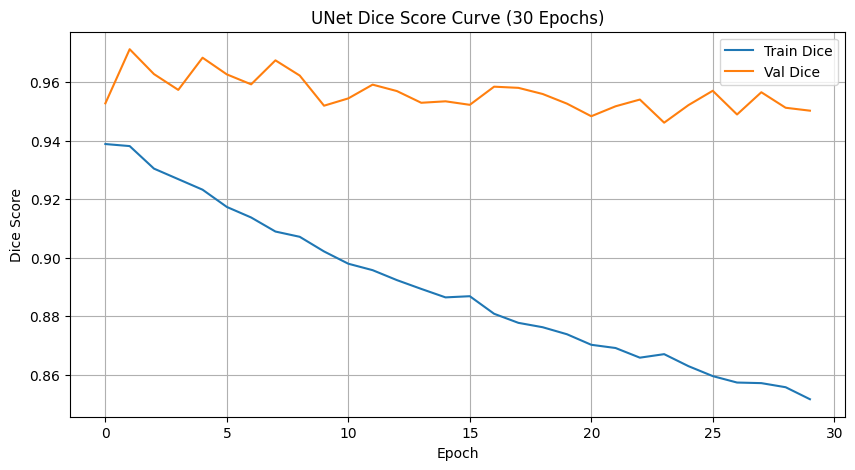

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_dice_hist, label="Train Dice")
plt.plot(val_dice_hist, label="Val Dice")
plt.title("UNet Dice Score Curve (30 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.grid(True)
plt.legend()
plt.show()
